In [74]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd 
import pickle
import json
# import requests
from scipy import signal
from datetime import date,timedelta
import copy

import datetime
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 
import datetime as dt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

In [75]:
# SHEDDING KERNEL

def non_uniform_savgol(x, y, window, polynom):
    """
    Applies a Savitzky-Golay filter to y with non-uniform spacing
    as defined in x

    ----------
    x : array_like
        List of floats representing the x values of the data (MUST BE ORDERED)
    y : array_like
        List of floats representing the y values. Must have same length
        as x
    window : int (odd)
        Window length of datapoints. Must be odd and smaller than x
    polynom : int
        The order of polynom used. Must be smaller than the window size

    Returns
    -------
    np.array of float
        The smoothed y values
    """
    if len(x) != len(y):
        raise ValueError('"x" and "y" must be of the same size')

    if len(x) < window:
        raise ValueError('The data size must be larger than the window size')

    if type(window) is not int:
        raise TypeError('"window" must be an integer')

    if window % 2 == 0:
        raise ValueError('The "window" must be an odd integer')

    if type(polynom) is not int:
        raise TypeError('"polynom" must be an integer')

    if polynom >= window:
        raise ValueError('"polynom" must be less than "window"')

    half_window = window // 2
    polynom += 1

    # Initialize variables
    A = np.empty((window, polynom))     # Matrix
    tA = np.empty((polynom, window))    # Transposed matrix
    t = np.empty(window)                # Local x variables
    y_smoothed = np.full(len(y), np.nan)

    # Start smoothing
    for i in range(half_window, len(x) - half_window, 1):
        # Center a window of x values on x[i]
        for j in range(0, window, 1):
            t[j] = x[i + j - half_window] - x[i]

        # Create the initial matrix A and its transposed form tA
        for j in range(0, window, 1):
            r = 1.0
            for k in range(0, polynom, 1):
                A[j, k] = r
                tA[k, j] = r
                r *= t[j]

        # Multiply the two matrices
        tAA = np.matmul(tA, A)

        # Invert the product of the matrices
        tAA = np.linalg.inv(tAA)

        # Calculate the pseudoinverse of the design matrix
        coeffs = np.matmul(tAA, tA)

        # Calculate c0 which is also the y value for y[i]
        y_smoothed[i] = 0
        for j in range(0, window, 1):
            y_smoothed[i] += coeffs[0, j] * y[i + j - half_window]

        # If at the end or beginning, store all coefficients for the polynom
        if i == half_window:
            first_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    first_coeffs[k] += coeffs[k, j] * y[j]
        elif i == len(x) - half_window - 1:
            last_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    last_coeffs[k] += coeffs[k, j] * y[len(y) - window + j]

    # Interpolate the result at the left border
    for i in range(0, half_window, 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += first_coeffs[j] * x_i
            x_i *= x[i] - x[half_window]

    # Interpolate the result at the right border
    for i in range(len(x) - half_window, len(x), 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += last_coeffs[j] * x_i
            x_i *= x[i] - x[-half_window - 1]

    return y_smoothed


cdf = pd.read_csv('/Users/elizabethmurphy/Downloads/PointLoma_sewage_qPCR.csv')
cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
cdf =cdf.set_index('Sample_Date')
import numpy as np

## interpolate qPCR data

numberDates = [dvi.value/10**11 for dvi in cdf.index]

cdf['Mean viral gene copies/L'] = non_uniform_savgol(numberDates,cdf['Mean viral gene copies/L'],5,1)
# convert to daily via interpolation
date_ind = pd.date_range(cdf.index.min(),cdf.index.max(),freq='D')
cdf = cdf.reindex(date_ind)
cdf = cdf.interpolate()

# fig,ax = plt.subplots()
# ax.plot(cdf.index,cdf['Mean viral gene copies/L'])
# ax.set_yscale('log')
# locator = mdates.AutoDateLocator()
# ax.xaxis.set_major_locator(locator)
# ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
# ax.set_xlim([cdf.index.min(),cdf.index.max()])
# plt.setp(ax.get_xticklabels(), rotation=90)
# ax.set_ylabel('Mean viral gene copies/L')
# fig.tight_layout()


#### now, solve the deconvolution problem to get a proxy for cases per day

# alpha = 0.3
# beta = alpha/0.624

# A = 1
# C0 = A*alpha/(beta-alpha)
t = np.linspace(0,40,41)
# c = C0*np.exp(-alpha*t)*(1-np.exp(-(beta-alpha)*t))
# ### estimate growth rates
# ## shedding kernel
def eclipse_model(y, t, b, k, delta, p, mu, c):
    T, I1, I2, Vi, Vni = y
    dydt = [-b*Vi*T, b*Vi*T - k*I1, k*I1- delta*I2, p*mu*I2 - c*Vi, p*(1.-mu)*I2 - c*Vni]
    return dydt

b = 5e-5#1.5e-5
c =10
k= 6#4
mu = 1.0e-4
p = 1e5#1.1e6
delta = 0.5#0.33
from scipy.integrate import odeint
y0 = [1.33e5, 0, 1./30, 0, 0]

sol = odeint(eclipse_model, y0, t, args=(b, k, delta, p, mu, c))

c = sol[:,3:].sum(axis=1)
#simulate simple 
# fig,ax = plt.subplots()
# ax.plot(np.arange(0,len(t),1),c)
# ax.set_yscale('log')
# ax.set_ylim([0,1000])


c = c/c.sum()
#simulate simple 
# fig,ax = plt.subplots()
# ax.plot(np.arange(0,len(t),1),c)
# ax.set_xlabel('Days since infection')
# ax.set_ylabel('Shedding Load Density')
# ax.set_yscale('log')
# ax.set_ylim([0,1000])



shed_df = pd.read_csv('/Users/elizabethmurphy/Downloads/inferred_kernel.csv',header=0,index_col='lags')['load']
shed_df = shed_df.apply(lambda x: 0 if x<0 else x)


# INFERRED CASES

# c = np.array(shed_df.iloc[1:].values)

c = c[1:] #drops first day, concentration=0
# c = c/np.sum(c)
cFlipped = c[::-1]
F = len(c)


# from scipy.signal import deconvolve
# recovered, remainder = deconvolve(cdf['Mean viral gene copies/L'], c)
# ### now convert ww trajectory into infections

tiledMat = np.zeros((len(cdf),len(cdf)))
for j in range(0,len(cdf)):
    tiledMat[j,np.max([j-len(c)+1,0]):(j+1)] = cFlipped[np.max([len(c)-j-1,0]):len(c)]

# tiledMat = tiledMat[F:(len(c)-F,:]
infects = np.dot(np.linalg.pinv(tiledMat),cdf)
infects = pd.Series(infects[:,0],index=cdf.index)

cases = pd.read_csv('/Users/elizabethmurphy/Downloads/cases.csv',index_col=0)
cases = cases[cases['catchment'] =='PointLoma']
cases = cases[(cases.index>='2021-04-01') & (cases.index<='2022-07-01')]
cases.index = pd.to_datetime(cases.index)
cases = cases.groupby(pd.Grouper(freq='D'))[['new_cases']].sum()
cases['cases'] = cases['new_cases'].rolling(window=7, center=True, min_periods=0).mean()


minInd = np.max([cdf.index.min(),cases.index.min()])
maxInd = np.min([cdf.index.max(),cases.index.max()])

cdf = cdf[cdf.index>=minInd]
cdf = cdf[cdf.index<=maxInd]

cases = cases[cases.index>=minInd]
cases = cases[cases.index<=maxInd]

infects = infects[infects.index>=minInd]
infects = infects[infects.index<=maxInd]



import cvxpy as cp
# least squares problem
x = cp.Variable(1)
cost = cp.norm(cp.multiply(infects,x) - cases['cases'],2)
## add some constraints on the shape of the curve. 
# constraints = [x >= 0]
prob = cp.Problem(cp.Minimize(cost))#,constraints)
prob.solve(solver=cp.CLARABEL) #, verbose=True)


infects = infects*x.value
infects = infects.astype(int)


/var/folders/s2/nry612l527j2xxdsq0_70h6m0000gn/T/ipykernel_69566/2782828678.py:111: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
/var/folders/s2/nry612l527j2xxdsq0_70h6m0000gn/T/ipykernel_69566/2782828678.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_smoothed[i] += coeffs[0, j] * y[i + j - half_window]
/var/folders/s2/nry612l527j2xxdsq0_70h6m0000gn/T/ipykernel_69566/2782828678.py:84: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se

In [76]:
xmin = pd.to_datetime("2021-04-11")
xmax = pd.to_datetime("2022-06-01")

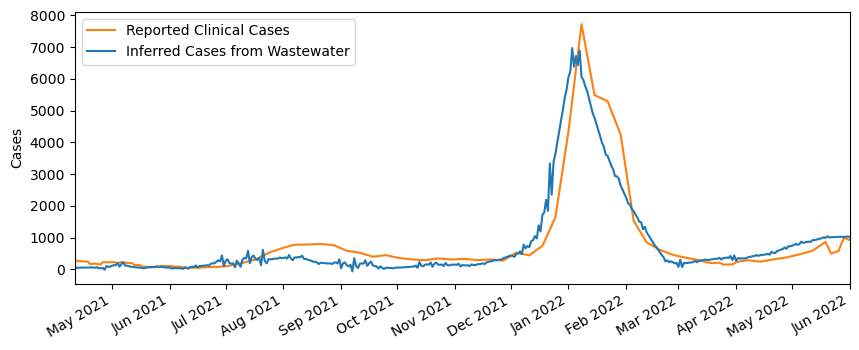

In [77]:
fig, ax = plt.subplots(1,1, figsize=(10, 4))
ax.plot(cdf.index,cases['cases'],color='#ff7f0e',label='Reported Clinical Cases')
ax.plot(cdf.index,infects,color='#1f77b4',label='Inferred Cases from Wastewater')
ax.set_ylabel('Cases')
plt.legend(loc='upper left')
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

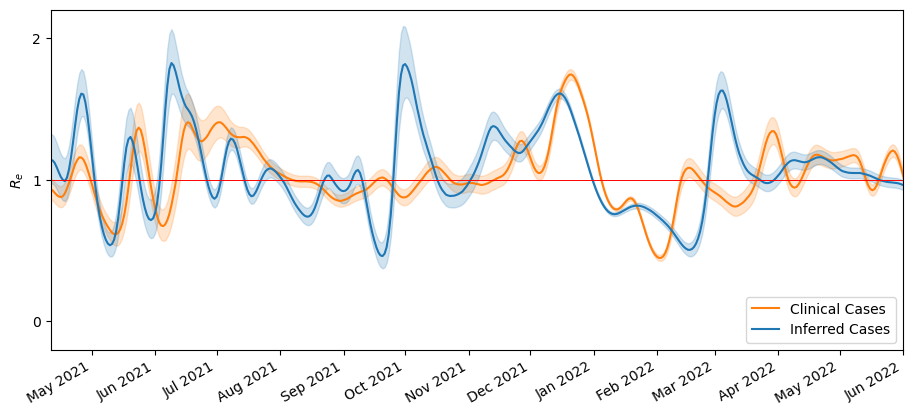

In [78]:
# EFFECTIVE REPRODUCTION NUMBER

infects = infects[infects>0]

import epyestim
import epyestim.covid19 as covid19

date_ind = pd.date_range(infects.index.min(),infects.index.max(),freq='D')
infects = infects.reindex(date_ind)
infects = infects.fillna(0)
# infects0 = pd.Series(infects[5:len(infects)-5,0],index=cdf.index[5:len(infects)-5])
ww_time_varying_r = covid19.r_covid(infects)
clin_time_varying_r = covid19.r_covid(cases['cases'])


fig, ax = plt.subplots(1,1, figsize=(11, 5))
ax.plot(clin_time_varying_r.index,clin_time_varying_r.loc[:,'Q0.5'],color='#ff7f0e',label='Clinical Cases')
ax.fill_between(clin_time_varying_r.index, clin_time_varying_r['Q0.025'], clin_time_varying_r['Q0.975'], color='#ff7f0e', alpha=0.2)
ax.plot(ww_time_varying_r.index,ww_time_varying_r.loc[:,'Q0.5'],color='#1f77b4',label='Inferred Cases')
ax.fill_between(ww_time_varying_r.index, ww_time_varying_r['Q0.025'], ww_time_varying_r['Q0.975'], color='#1f77b4', alpha=0.2)
ax.set_ylabel('$R_e$')
ax.set_ylim([-0.2, 2.2])
ax.set_xlim(xmin, xmax)
ax.set_yticks([0, 1, 2])
ax.axhline(y=1, color='red',linewidth=.7)
plt.legend(loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

Text(0, 0.5, 'Shedding load density')

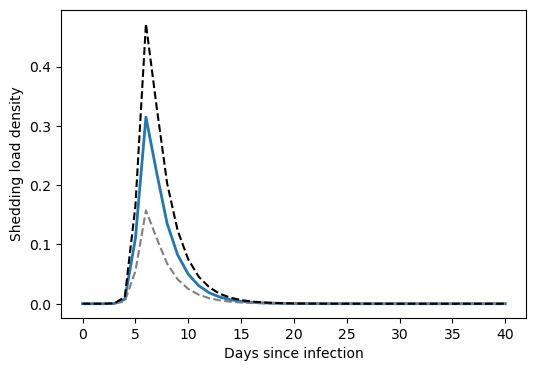

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Simulate eclipse model
def eclipse_model(y, t, b, k, delta, p, mu, c):
    T, I1, I2, Vi, Vni = y
    dydt = [-b*Vi*T, b*Vi*T - k*I1, k*I1- delta*I2, p*mu*I2 - c*Vi, p*(1.-mu)*I2 - c*Vni]
    return dydt

# Parameters
b = 5e-5
c_param = 10
k = 6
mu = 1.0e-4
p = 1e5
delta = 0.5
y0 = [1.33e5, 0, 1./30, 0, 0]
t = np.linspace(0, 40, 41)

# Solve ODE
sol = odeint(eclipse_model, y0, t, args=(b, k, delta, p, mu, c_param))
c = sol[:, 3:].sum(axis=1)
c = c / c.sum()  # Normalize to sum to 1 — this is S

# Create scaled versions of the shedding kernel
S = c
S_low = 0.5 * S
S_high = 1.5 * S

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, S, linewidth=2)
ax.plot(t, S_low, '--', color='gray')
ax.plot(t, S_high, '--', color='black')
ax.set_xlabel("Days since infection")
ax.set_ylabel("Shedding load density")

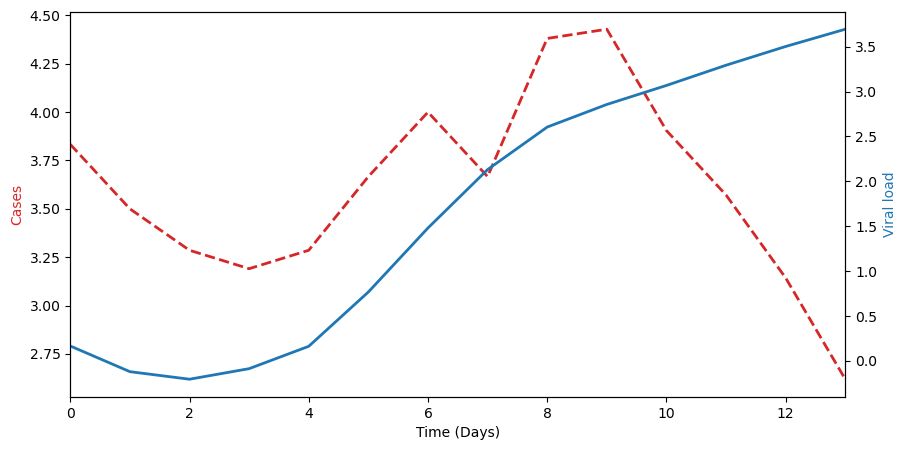

In [ ]:
n = 100
days = 14
infection_days = np.random.randint(0, days, size=n)
time = np.arange(days)
full_shedding = np.zeros(days)


for t in range(days):
    for d in infection_days:
        shedding_day = t - d
        if 0 <= shedding_day < len(c):
            full_shedding[t] += c[shedding_day]

smoothed_shedding = non_uniform_savgol(time, full_shedding, 7, 2)

case_counts = np.zeros(days)
for d in infection_days:
    case_counts[d] += 1

smoothed_cases = non_uniform_savgol(time, case_counts, 7, 2)



fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(time, smoothed_cases, color='tab:red', linestyle='--', linewidth=2)
ax1.set_xlabel('Time (Days)')
ax1.set_ylabel('Cases', color='tab:red')
ax1.tick_params(axis='y')
ax1.set_xlim(0, days - 1)

ax2 = ax1.twinx()
ax2.plot(time, smoothed_shedding, color='tab:blue', linewidth=2)
ax2.set_ylabel('Viral load', color='tab:blue')
ax2.tick_params(axis='y')